## IMU shake-based time sync (Ovidi -> Phone -> Location)
Use early shake signals to estimate clock offset, then map Ovidi timestamps to Location time (ns).


In [ ]:
from pathlib import Path

# data_dir = Path('03_10/_23-2026-03-10_09-32-10')
data_dir = Path('03_11_sync_test/_-2026-03-11_04-30-42')

# Fix to the requested recording session for sync.
ovidi_path = data_dir / 'OvidiDevice.csv'
phone_acc_path = data_dir / 'AccelerometerUncalibrated.csv'
phone_gyro_path = data_dir / 'Gyroscope.csv'
location_path = data_dir / 'Location.csv'

Sync signal: accel_norm_dynamic + 1.00 * gyro_norm_dynamic
Ovidi -> Phone offset: +69891.673700 s
Best lag in xcorr window: +1.510 s | score: 0.758
Ovidi aligned range(ns): 1773203443810700544 .. 1773203524495700480
Location range(ns):      1773203442390000000 .. 1773203514604298500
Nearest Location within 0.5s: 29.11%
Nearest dt median: 1.396s | p95: 5.838s


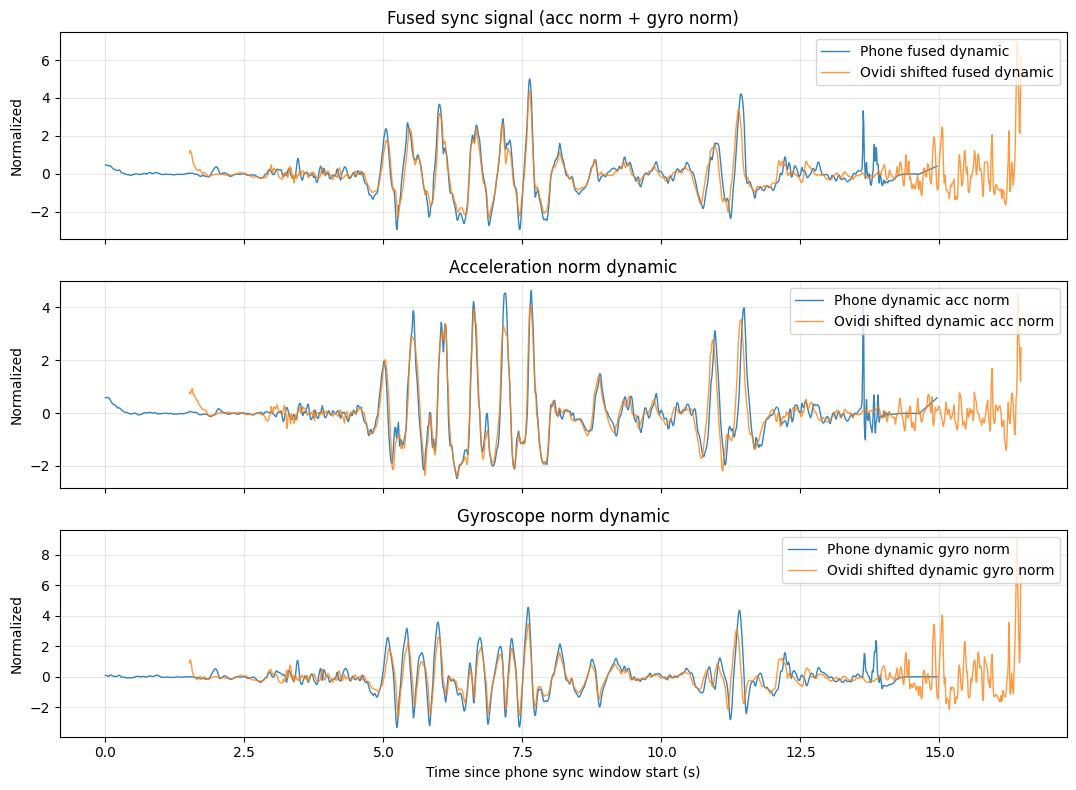

In [ ]:
# IMU shake-based time sync: OvidiDevice -> Phone(Accelerometer + Gyroscope) -> Location
import csv, math
import numpy as np
import matplotlib.pyplot as plt

sync_window_s = 15.0
fs_hz = 100.0
max_lag_s = 15.0
gyro_weight = 1.0  # fused signal = accel_dynamic + gyro_weight * gyro_dynamic

def read_xyz_csv(path, time_key, xyz_keys, time_scale=1.0):
    t, x, y, z = [], [], [], []
    with path.open() as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                ti = float(row[time_key]) * time_scale
                xi = float(row[xyz_keys[0]])
                yi = float(row[xyz_keys[1]])
                zi = float(row[xyz_keys[2]])
            except (KeyError, ValueError, TypeError):
                continue
            if not (math.isfinite(ti) and math.isfinite(xi) and math.isfinite(yi) and math.isfinite(zi)):
                continue
            t.append(ti)
            x.append(xi)
            y.append(yi)
            z.append(zi)
    if not t:
        raise ValueError(f'No valid rows in {path}')
    return np.asarray(t, dtype=np.float64), np.column_stack([x, y, z]).astype(np.float64)

def read_location_time(path):
    t_ns = []
    with path.open() as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                t_ns.append(int(row['time']))
            except (KeyError, ValueError, TypeError):
                continue
    if not t_ns:
        raise ValueError(f'No valid location times in {path}')
    return np.asarray(t_ns, dtype=np.int64)

def trim_to_window(t_s, xyz, window_s):
    mask = (t_s - t_s[0]) <= window_s
    return t_s[mask], xyz[mask]

def preprocess_norm_dynamic(t_s, xyz, fs_hz=100.0, hp_window_s=0.7):
    if len(t_s) < 10:
        raise ValueError('Not enough IMU samples')

    sig_norm = np.linalg.norm(xyz, axis=1)
    mask = np.isfinite(t_s) & np.isfinite(sig_norm)
    t_s = t_s[mask]
    sig_norm = sig_norm[mask]

    order = np.argsort(t_s)
    t_s = t_s[order]
    sig_norm = sig_norm[order]

    uniq = np.concatenate(([True], np.diff(t_s) > 0))
    t_s = t_s[uniq]
    sig_norm = sig_norm[uniq]

    if len(t_s) < 10:
        raise ValueError('Not enough unique IMU samples')

    t_grid = np.arange(t_s[0], t_s[-1], 1.0 / fs_hz)
    if len(t_grid) < 10:
        raise ValueError('Not enough resampled IMU samples')

    sig_i = np.interp(t_grid, t_s, sig_norm)

    # Remove slow trend and keep shake-like dynamics.
    w = max(int(fs_hz * hp_window_s), 3)
    kernel = np.ones(w, dtype=np.float64) / w
    low = np.convolve(sig_i, kernel, mode='same')
    dynamic = sig_i - low
    dynamic = (dynamic - dynamic.mean()) / (dynamic.std() + 1e-9)

    return t_grid, dynamic

def build_fused_signal(acc_t_s, acc_xyz, gyro_t_s, gyro_xyz, fs_hz=100.0, gyro_weight=1.0):
    acc_grid, acc_dyn = preprocess_norm_dynamic(acc_t_s, acc_xyz, fs_hz=fs_hz)
    gyro_grid, gyro_dyn = preprocess_norm_dynamic(gyro_t_s, gyro_xyz, fs_hz=fs_hz)

    fuse_start_s = max(acc_grid[0], gyro_grid[0])
    fuse_end_s = min(acc_grid[-1], gyro_grid[-1])
    if fuse_end_s <= fuse_start_s:
        raise ValueError('No overlap between accel and gyro timelines')

    t_grid = np.arange(fuse_start_s, fuse_end_s, 1.0 / fs_hz)
    if len(t_grid) < int(fs_hz * 3):
        raise ValueError('Overlap between accel and gyro is too short')

    acc_i = np.interp(t_grid, acc_grid, acc_dyn)
    gyro_i = np.interp(t_grid, gyro_grid, gyro_dyn)

    fused = acc_i + gyro_weight * gyro_i
    fused = (fused - fused.mean()) / (fused.std() + 1e-9)

    return t_grid, fused, acc_i, gyro_i

def estimate_offset(
    ov_acc_t_s, ov_acc, ov_gyro_t_s, ov_gyro,
    ph_acc_t_s, ph_acc, ph_gyro_t_s, ph_gyro,
    sync_window_s=10.0, fs_hz=100.0, max_lag_s=15.0, gyro_weight=1.0
):
    ov_acc_t_w, ov_acc_w = trim_to_window(ov_acc_t_s, ov_acc, sync_window_s)
    ov_gyro_t_w, ov_gyro_w = trim_to_window(ov_gyro_t_s, ov_gyro, sync_window_s)
    ph_acc_t_w, ph_acc_w = trim_to_window(ph_acc_t_s, ph_acc, sync_window_s)
    ph_gyro_t_w, ph_gyro_w = trim_to_window(ph_gyro_t_s, ph_gyro, sync_window_s)

    ov_grid_s, ov_sig, ov_acc_dyn, ov_gyro_dyn = build_fused_signal(
        ov_acc_t_w, ov_acc_w, ov_gyro_t_w, ov_gyro_w, fs_hz=fs_hz, gyro_weight=gyro_weight
    )
    ph_grid_s, ph_sig, ph_acc_dyn, ph_gyro_dyn = build_fused_signal(
        ph_acc_t_w, ph_acc_w, ph_gyro_t_w, ph_gyro_w, fs_hz=fs_hz, gyro_weight=gyro_weight
    )

    n = min(len(ov_sig), len(ph_sig))
    if n < int(fs_hz * 5):
        raise ValueError('Overlap is too short for robust sync')

    ov_grid_s = ov_grid_s[:n]
    ov_sig = ov_sig[:n]
    ov_acc_dyn = ov_acc_dyn[:n]
    ov_gyro_dyn = ov_gyro_dyn[:n]

    ph_grid_s = ph_grid_s[:n]
    ph_sig = ph_sig[:n]
    ph_acc_dyn = ph_acc_dyn[:n]
    ph_gyro_dyn = ph_gyro_dyn[:n]

    # Positive lag means Ovidi signal should move later relative to phone signal.
    corr = np.correlate(ph_sig, ov_sig, mode='full')
    lags = np.arange(-n + 1, n, dtype=np.float64) / fs_hz

    valid = np.abs(lags) <= max_lag_s
    if not np.any(valid):
        raise ValueError('No valid lag range for cross-correlation')

    valid_lags = lags[valid]
    valid_corr = corr[valid]
    best_lag_s = float(valid_lags[np.argmax(valid_corr)])

    offset_s = float((ph_grid_s[0] - ov_grid_s[0]) + best_lag_s)
    score = float(valid_corr.max() / n)

    return (
        offset_s,
        best_lag_s,
        score,
        ov_grid_s,
        ov_sig,
        ov_acc_dyn,
        ov_gyro_dyn,
        ph_grid_s,
        ph_sig,
        ph_acc_dyn,
        ph_gyro_dyn,
    )

ov_acc_t_s, ov_acc = read_xyz_csv(ovidi_path, 'timestamp', ('AccX', 'AccY', 'AccZ'))
ov_gyro_t_s, ov_gyro = read_xyz_csv(ovidi_path, 'timestamp', ('GyroX', 'GyroY', 'GyroZ'))
ph_acc_t_s, ph_acc = read_xyz_csv(phone_acc_path, 'time', ('x', 'y', 'z'), time_scale=1e-9)
ph_gyro_t_s, ph_gyro = read_xyz_csv(phone_gyro_path, 'time', ('x', 'y', 'z'), time_scale=1e-9)
loc_t_ns = read_location_time(location_path)

(
    ovidi_to_phone_offset_s,
    best_lag_s,
    xcorr_score,
    ov_fused_t,
    ov_fused_sig,
    ov_acc_dyn,
    ov_gyro_dyn,
    ph_fused_t,
    ph_fused_sig,
    ph_acc_dyn,
    ph_gyro_dyn,
) = estimate_offset(
    ov_acc_t_s, ov_acc, ov_gyro_t_s, ov_gyro,
    ph_acc_t_s, ph_acc, ph_gyro_t_s, ph_gyro,
    sync_window_s=sync_window_s,
    fs_hz=fs_hz,
    max_lag_s=max_lag_s,
    gyro_weight=gyro_weight,
)

# This is the key synced timeline: same absolute epoch as Accelerometer/Location.time (ns).
ovidi_aligned_time_ns = np.rint((ov_acc_t_s + ovidi_to_phone_offset_s) * 1e9).astype(np.int64)

# Check nearest Location match quality after sync.
loc_t_ns_sorted = np.sort(loc_t_ns)
ov_sorted_ns = np.sort(ovidi_aligned_time_ns)
idx = np.searchsorted(loc_t_ns_sorted, ov_sorted_ns)

left_idx = np.clip(idx - 1, 0, len(loc_t_ns_sorted) - 1)
right_idx = np.clip(idx, 0, len(loc_t_ns_sorted) - 1)
left_dt = np.abs(ov_sorted_ns - loc_t_ns_sorted[left_idx])
right_dt = np.abs(ov_sorted_ns - loc_t_ns_sorted[right_idx])
use_right = right_dt < left_dt
nearest_dt_ns = np.where(use_right, right_dt, left_dt)

tol_ns = int(0.5e9)
match_mask = nearest_dt_ns <= tol_ns

print(f'Sync signal: accel_norm_dynamic + {gyro_weight:.2f} * gyro_norm_dynamic')
print(f'Ovidi -> Phone offset: {ovidi_to_phone_offset_s:+.6f} s')
print(f'Best lag in xcorr window: {best_lag_s:+.3f} s | score: {xcorr_score:.3f}')
print(f'Ovidi aligned range(ns): {ovidi_aligned_time_ns[0]} .. {ovidi_aligned_time_ns[-1]}')
print(f'Location range(ns):      {loc_t_ns_sorted[0]} .. {loc_t_ns_sorted[-1]}')
print(f'Nearest Location within {tol_ns/1e9:.1f}s: {match_mask.mean() * 100:.2f}%')
print(f'Nearest dt median: {np.median(nearest_dt_ns) / 1e9:.3f}s | p95: {np.percentile(nearest_dt_ns, 95) / 1e9:.3f}s')

# Visual check: fused signal + each component dynamic signal.
t0 = ph_fused_t[0]
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(ph_fused_t - t0, ph_fused_sig, label='Phone fused dynamic', linewidth=1.0, alpha=0.9)
axes[0].plot((ov_fused_t + ovidi_to_phone_offset_s) - t0, ov_fused_sig, label='Ovidi shifted fused dynamic', linewidth=1.0, alpha=0.8)
axes[0].set_ylabel('Normalized')
axes[0].set_title('Fused sync signal (acc norm + gyro norm)')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(ph_fused_t - t0, ph_acc_dyn, label='Phone dynamic acc norm', linewidth=1.0, alpha=0.9)
axes[1].plot((ov_fused_t + ovidi_to_phone_offset_s) - t0, ov_acc_dyn, label='Ovidi shifted dynamic acc norm', linewidth=1.0, alpha=0.8)
axes[1].set_ylabel('Normalized')
axes[1].set_title('Acceleration norm dynamic')
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper right')

axes[2].plot(ph_fused_t - t0, ph_gyro_dyn, label='Phone dynamic gyro norm', linewidth=1.0, alpha=0.9)
axes[2].plot((ov_fused_t + ovidi_to_phone_offset_s) - t0, ov_gyro_dyn, label='Ovidi shifted dynamic gyro norm', linewidth=1.0, alpha=0.8)
axes[2].set_xlabel('Time since phone sync window start (s)')
axes[2].set_ylabel('Normalized')
axes[2].set_title('Gyroscope norm dynamic')
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

# Optional export with synced absolute time.
save_synced_csv = False
if save_synced_csv:
    synced_path = data_dir / 'OvidiDevice_time_synced.csv'
    with ovidi_path.open() as f_in, synced_path.open('w', newline='') as f_out:
        reader = csv.DictReader(f_in)
        fieldnames = list(reader.fieldnames or []) + ['timestamp_aligned_sec', 'time_aligned_ns']
        writer = csv.DictWriter(f_out, fieldnames=fieldnames)
        writer.writeheader()
        for row in reader:
            try:
                ts = float(row['timestamp'])
                ts_aligned = ts + ovidi_to_phone_offset_s
                t_ns = int(round(ts_aligned * 1e9))
            except (KeyError, ValueError, TypeError):
                ts_aligned = ''
                t_ns = ''
            row['timestamp_aligned_sec'] = ts_aligned
            row['time_aligned_ns'] = t_ns
            writer.writerow(row)
    print(f'Saved: {synced_path}')


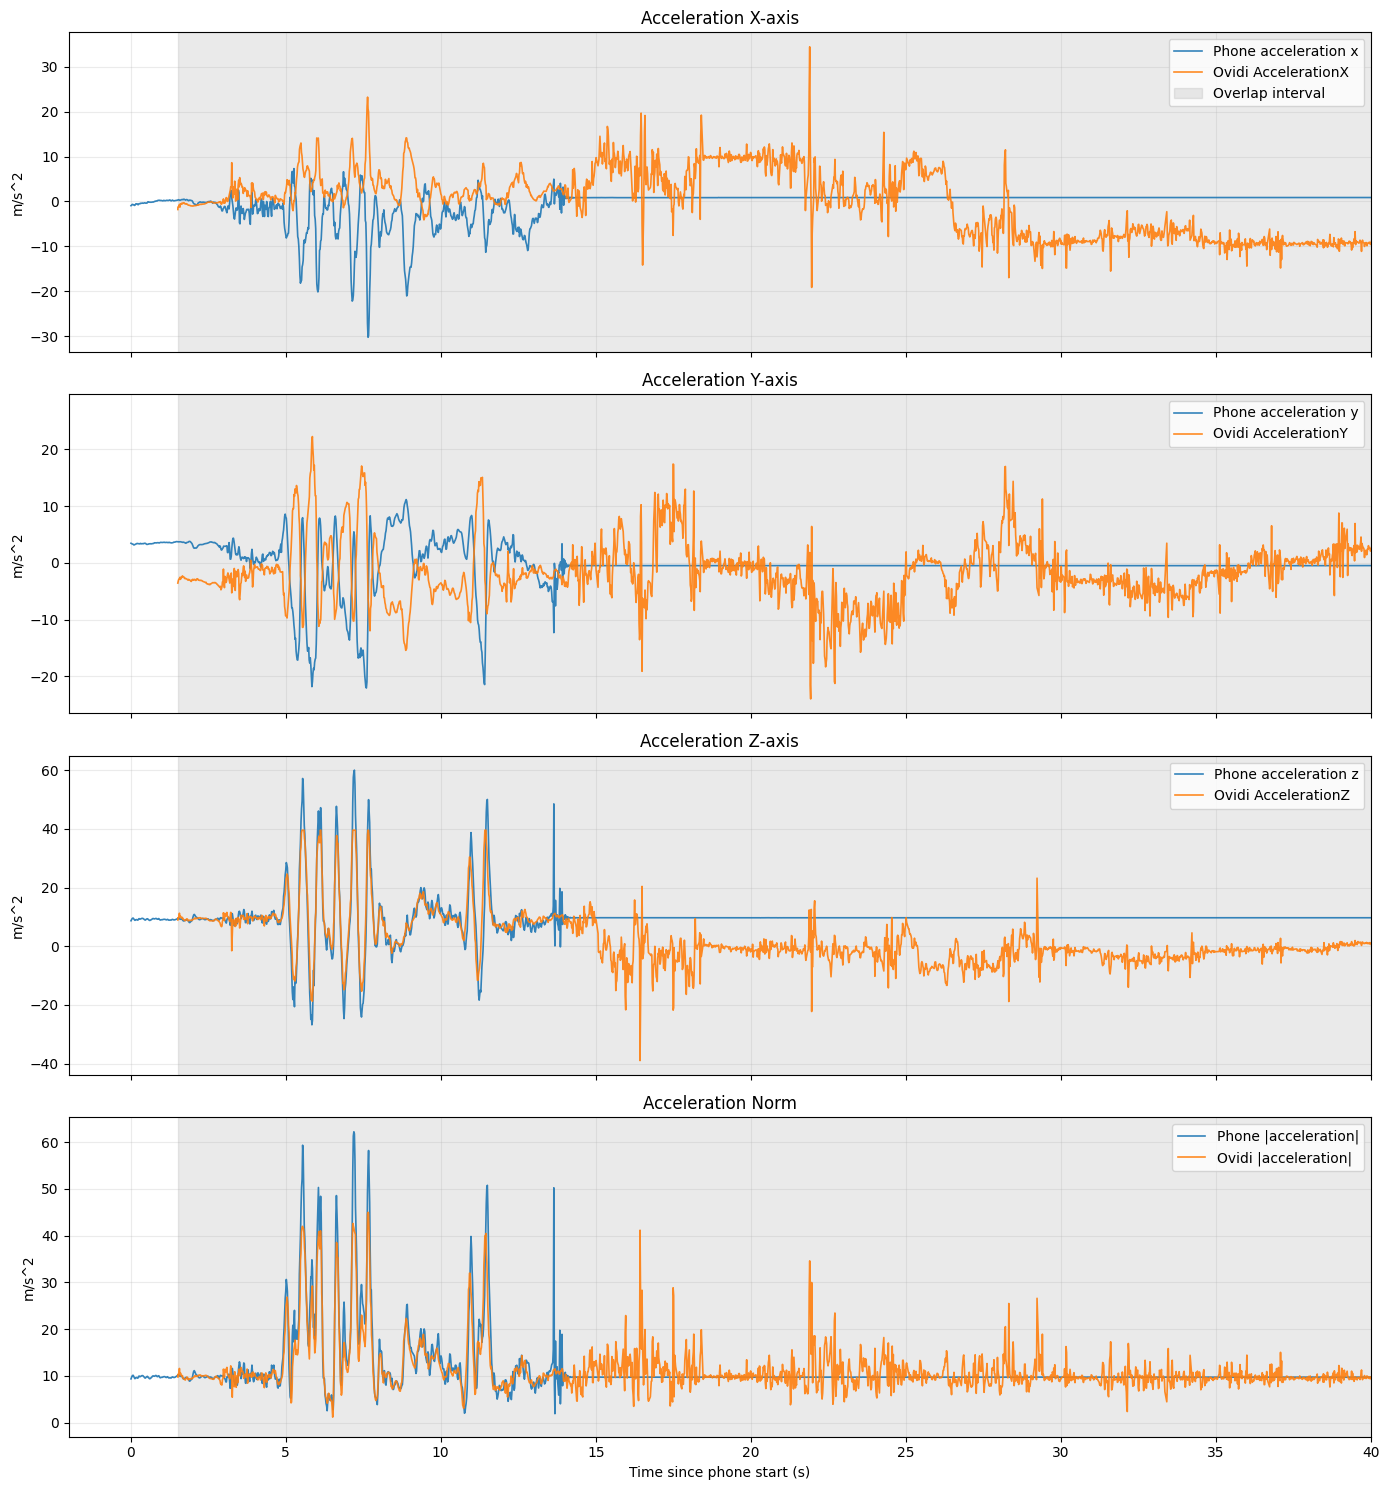

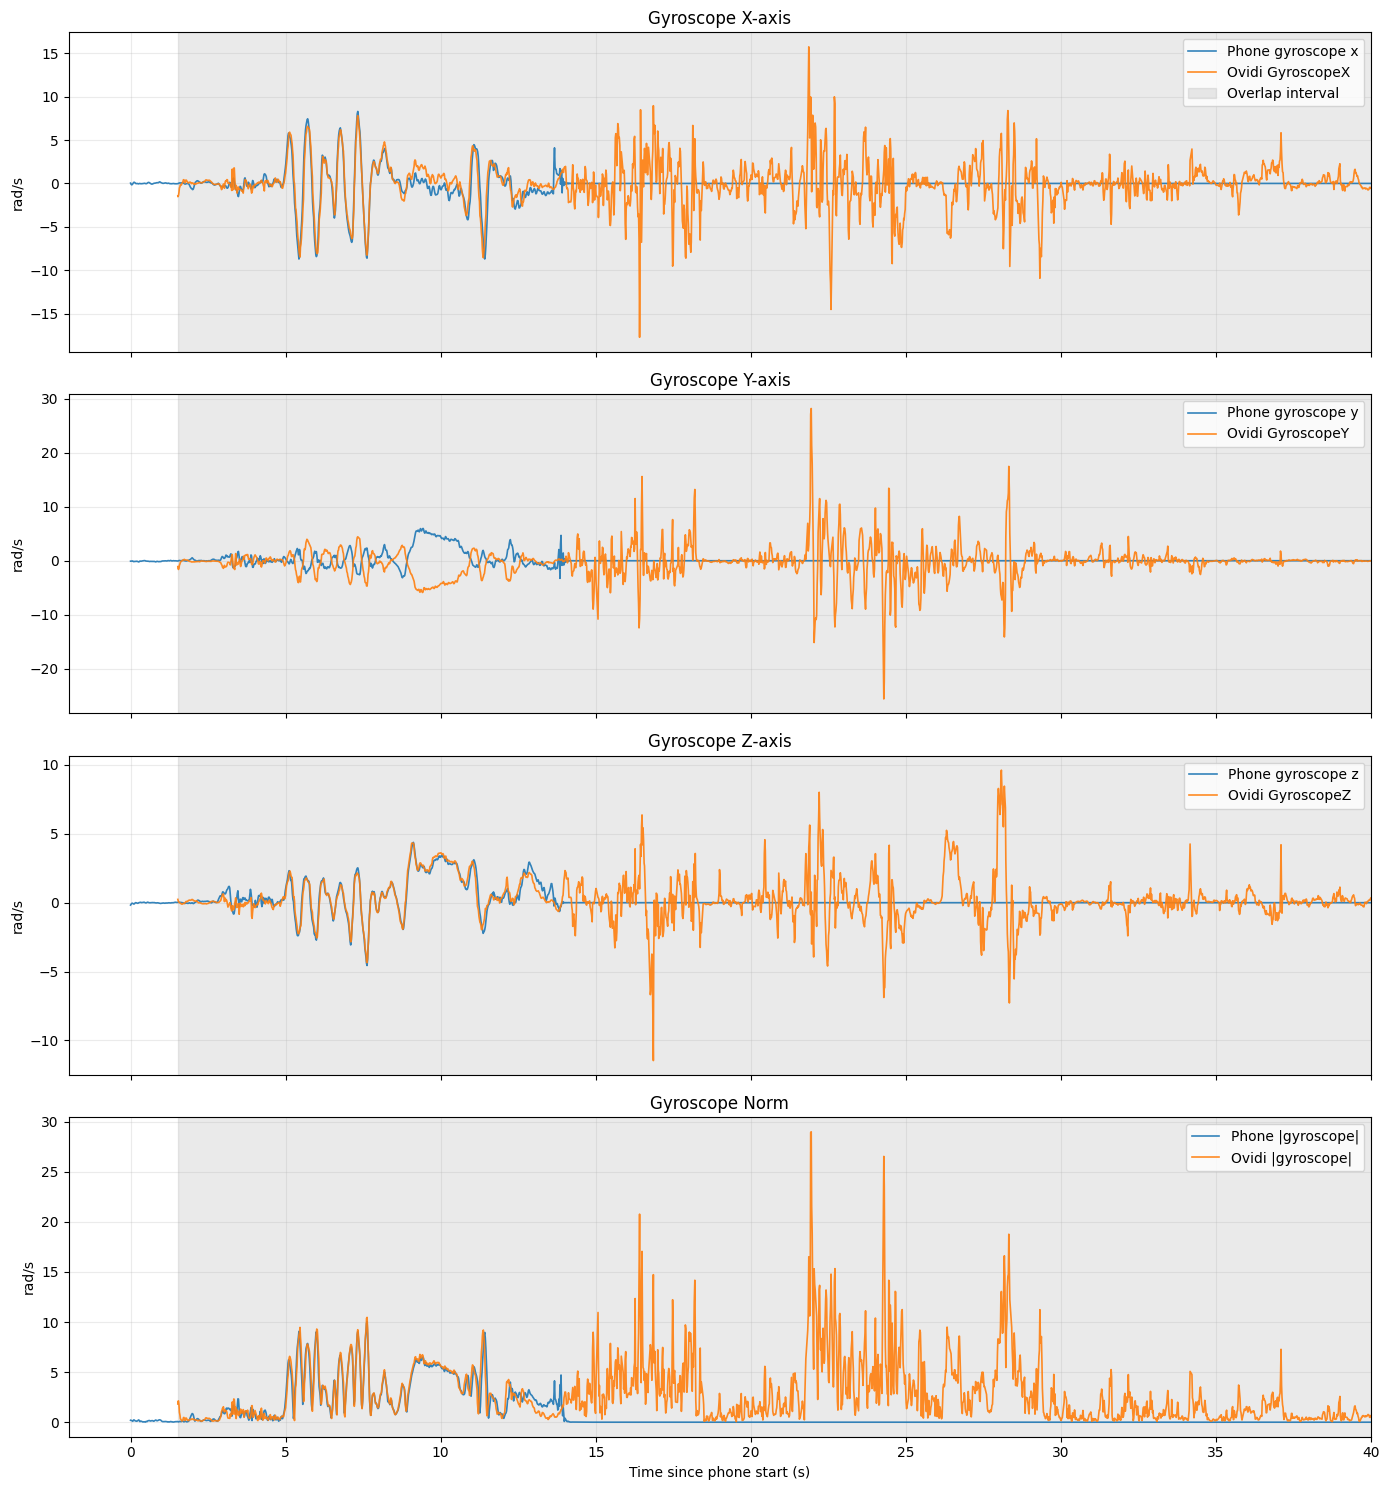

View mode: first_n_sec | x-range: [-2.000, 40.000] s
Overlap on aligned timeline: 1773203443.811s ~ 1773203515.919s (72.108s)
Norm correlation (overlap, aligned): acc=0.7192 (n=4105), gyro=0.2158 (n=4105)


In [32]:
# Ovidi vs Phone: 3-axis + norm comparison (Acceleration + Gyroscope)
from pathlib import Path
import csv, math
import numpy as np
import matplotlib.pyplot as plt

# View options (time axis = seconds since phone start)
# - 'full': entire timeline
# - 'first_n_sec': show [0, view_first_n_sec]
# - 'custom': show [view_start_s, view_end_s]
view_mode = 'first_n_sec'
view_first_n_sec = 40.0
view_start_s = 155.0
view_end_s = 185.0

def read_ovidi_sensor(path, xyz_keys):
    t_s, x, y, z = [], [], [], []
    with path.open() as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                ti = float(row['timestamp'])
                xi = float(row[xyz_keys[0]])
                yi = float(row[xyz_keys[1]])
                zi = float(row[xyz_keys[2]])
            except (KeyError, ValueError, TypeError):
                continue
            if not (math.isfinite(ti) and math.isfinite(xi) and math.isfinite(yi) and math.isfinite(zi)):
                continue
            t_s.append(ti)
            x.append(xi)
            y.append(yi)
            z.append(zi)
    return np.asarray(t_s), np.asarray(x), np.asarray(y), np.asarray(z)

def read_phone_sensor(path):
    t_s, x, y, z = [], [], [], []
    with path.open() as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                ti = float(row['time']) * 1e-9
                xi = float(row['x'])
                yi = float(row['y'])
                zi = float(row['z'])
            except (KeyError, ValueError, TypeError):
                continue
            if not (math.isfinite(ti) and math.isfinite(xi) and math.isfinite(yi) and math.isfinite(zi)):
                continue
            t_s.append(ti)
            x.append(xi)
            y.append(yi)
            z.append(zi)
    return np.asarray(t_s), np.asarray(x), np.asarray(y), np.asarray(z)

def compute_overlap_norm_corr(ph_t_s, ph_norm, ov_t_aligned_s, ov_norm):
    overlap_start = max(ph_t_s.min(), ov_t_aligned_s.min())
    overlap_end = min(ph_t_s.max(), ov_t_aligned_s.max())
    if overlap_end <= overlap_start:
        return float('nan'), 0

    mask = (ph_t_s >= overlap_start) & (ph_t_s <= overlap_end)
    if np.count_nonzero(mask) < 3:
        return float('nan'), int(np.count_nonzero(mask))

    ov_interp = np.interp(ph_t_s[mask], ov_t_aligned_s, ov_norm)
    corr = np.corrcoef(ph_norm[mask], ov_interp)[0, 1]
    return float(corr), int(np.count_nonzero(mask))

def plot_sensor_panels(
    title_prefix,
    unit_label,
    ov_plot_t,
    ph_plot_t,
    ov_x,
    ov_y,
    ov_z,
    ph_x,
    ph_y,
    ph_z,
    has_overlap,
    overlap_start_rel,
    overlap_end_rel,
    x_min,
    x_max,
):
    ov_norm = np.sqrt(ov_x**2 + ov_y**2 + ov_z**2)
    ph_norm = np.sqrt(ph_x**2 + ph_y**2 + ph_z**2)

    axis_map = [
        ('X', ov_x, ph_x, f'Ovidi {title_prefix}X', f'Phone {title_prefix.lower()} x'),
        ('Y', ov_y, ph_y, f'Ovidi {title_prefix}Y', f'Phone {title_prefix.lower()} y'),
        ('Z', ov_z, ph_z, f'Ovidi {title_prefix}Z', f'Phone {title_prefix.lower()} z'),
        ('Norm', ov_norm, ph_norm, f'Ovidi |{title_prefix.lower()}|', f'Phone |{title_prefix.lower()}|'),
    ]

    fig, axes = plt.subplots(4, 1, figsize=(14, 15), sharex=True)

    for i, (axis_name, ov_axis, ph_axis, ov_label, ph_label) in enumerate(axis_map):
        ax = axes[i]
        ax.plot(ph_plot_t, ph_axis, label=ph_label, linewidth=1.2, alpha=0.9)
        ax.plot(ov_plot_t, ov_axis, label=ov_label, linewidth=1.2, alpha=0.9)

        if has_overlap:
            ax.axvspan(
                overlap_start_rel,
                overlap_end_rel,
                color='gray',
                alpha=0.16,
                label='Overlap interval' if i == 0 else None,
            )

        panel_title = f'{title_prefix} {axis_name}-axis' if axis_name != 'Norm' else f'{title_prefix} Norm'
        ax.set_title(panel_title)
        ax.set_ylabel(unit_label)
        ax.set_xlim(x_min, x_max)
        ax.grid(True, alpha=0.25)
        ax.legend(loc='upper right')

    axes[-1].set_xlabel('Time since phone start (s)')
    plt.tight_layout()
    plt.show()

ov_acc_t_s, ov_acc_x, ov_acc_y, ov_acc_z = read_ovidi_sensor(ovidi_path, ('AccX', 'AccY', 'AccZ'))
ph_acc_t_s, ph_acc_x, ph_acc_y, ph_acc_z = read_phone_sensor(phone_acc_path)
ov_gyro_t_s, ov_gyro_x, ov_gyro_y, ov_gyro_z = read_ovidi_sensor(ovidi_path, ('GyroX', 'GyroY', 'GyroZ'))
ph_gyro_t_s, ph_gyro_x, ph_gyro_y, ph_gyro_z = read_phone_sensor(phone_gyro_path)

if len(ov_acc_t_s) == 0 or len(ph_acc_t_s) == 0 or len(ov_gyro_t_s) == 0 or len(ph_gyro_t_s) == 0:
    raise ValueError('No valid accelerometer/gyroscope rows found')

if 'ovidi_to_phone_offset_s' in globals():
    offset_s = float(ovidi_to_phone_offset_s)
else:
    offset_s = float(ph_acc_t_s[0] - ov_acc_t_s[0])
    print(f'[warn] ovidi_to_phone_offset_s not found. Fallback offset (start-time diff): {offset_s:+.6f}s')

ov_acc_t_aligned_s = ov_acc_t_s + offset_s
ov_gyro_t_aligned_s = ov_gyro_t_s + offset_s

t0 = min(ph_acc_t_s[0], ph_gyro_t_s[0])
ph_acc_plot_t = ph_acc_t_s - t0
ph_gyro_plot_t = ph_gyro_t_s - t0
ov_acc_plot_t = ov_acc_t_aligned_s - t0
ov_gyro_plot_t = ov_gyro_t_aligned_s - t0

overlap_start_s = max(
    ov_acc_t_aligned_s.min(),
    ph_acc_t_s.min(),
    ov_gyro_t_aligned_s.min(),
    ph_gyro_t_s.min(),
)
overlap_end_s = min(
    ov_acc_t_aligned_s.max(),
    ph_acc_t_s.max(),
    ov_gyro_t_aligned_s.max(),
    ph_gyro_t_s.max(),
)
has_overlap = overlap_end_s > overlap_start_s

overlap_start_rel = overlap_start_s - t0
overlap_end_rel = overlap_end_s - t0

x_global_min = float(min(ov_acc_plot_t.min(), ph_acc_plot_t.min(), ov_gyro_plot_t.min(), ph_gyro_plot_t.min()))
x_global_max = float(max(ov_acc_plot_t.max(), ph_acc_plot_t.max(), ov_gyro_plot_t.max(), ph_gyro_plot_t.max()))

if view_mode == 'full':
    x_min, x_max = x_global_min, x_global_max
elif view_mode == 'first_n_sec':
    x_min, x_max = -2.0, float(view_first_n_sec)
elif view_mode == 'custom':
    x_min, x_max = float(view_start_s), float(view_end_s)
else:
    raise ValueError(f'Unknown view_mode: {view_mode}')

if x_max <= x_min:
    raise ValueError('Invalid view range: x_max must be greater than x_min')

plot_sensor_panels(
    title_prefix='Acceleration',
    unit_label='m/s^2',
    ov_plot_t=ov_acc_plot_t,
    ph_plot_t=ph_acc_plot_t,
    ov_x=ov_acc_x,
    ov_y=ov_acc_y,
    ov_z=ov_acc_z,
    ph_x=ph_acc_x,
    ph_y=ph_acc_y,
    ph_z=ph_acc_z,
    has_overlap=has_overlap,
    overlap_start_rel=overlap_start_rel,
    overlap_end_rel=overlap_end_rel,
    x_min=x_min,
    x_max=x_max,
)

plot_sensor_panels(
    title_prefix='Gyroscope',
    unit_label='rad/s',
    ov_plot_t=ov_gyro_plot_t,
    ph_plot_t=ph_gyro_plot_t,
    ov_x=ov_gyro_x,
    ov_y=ov_gyro_y,
    ov_z=ov_gyro_z,
    ph_x=ph_gyro_x,
    ph_y=ph_gyro_y,
    ph_z=ph_gyro_z,
    has_overlap=has_overlap,
    overlap_start_rel=overlap_start_rel,
    overlap_end_rel=overlap_end_rel,
    x_min=x_min,
    x_max=x_max,
)

ov_acc_norm = np.sqrt(ov_acc_x**2 + ov_acc_y**2 + ov_acc_z**2)
ph_acc_norm = np.sqrt(ph_acc_x**2 + ph_acc_y**2 + ph_acc_z**2)
ov_gyro_norm = np.sqrt(ov_gyro_x**2 + ov_gyro_y**2 + ov_gyro_z**2)
ph_gyro_norm = np.sqrt(ph_gyro_x**2 + ph_gyro_y**2 + ph_gyro_z**2)

acc_norm_corr, acc_n = compute_overlap_norm_corr(ph_acc_t_s, ph_acc_norm, ov_acc_t_aligned_s, ov_acc_norm)
gyro_norm_corr, gyro_n = compute_overlap_norm_corr(ph_gyro_t_s, ph_gyro_norm, ov_gyro_t_aligned_s, ov_gyro_norm)

print(f'View mode: {view_mode} | x-range: [{x_min:.3f}, {x_max:.3f}] s')
if has_overlap:
    print(
        f'Overlap on aligned timeline: {overlap_start_s:.3f}s ~ {overlap_end_s:.3f}s '
        f'({overlap_end_s - overlap_start_s:.3f}s)'
    )
else:
    print('No overlap between Ovidi and Phone timelines after alignment')

print(f'Norm correlation (overlap, aligned): acc={acc_norm_corr:.4f} (n={acc_n}), gyro={gyro_norm_corr:.4f} (n={gyro_n})')


In [33]:
ovidi_to_phone_offset_s

69891.67370034217

## GPS Location Distance

In [ ]:
# CSV 읽기
points = []
with location_path.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            lat = float(row['latitude'])
            lon = float(row['longitude'])
        except (KeyError, ValueError):
            continue
        if math.isnan(lat) or math.isnan(lon):
            continue
        if lat == 0.0 and lon == 0.0:
            continue
        points.append((lat, lon))

len(points)


29

In [ ]:
# GPS 샘플링 주파수 계산 (Location.csv)
import statistics as stats

times_ns = []
with location_path.open() as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            times_ns.append(int(row['time']))
        except (KeyError, ValueError):
            continue

# 연속 샘플 간 간격(ns) 계산
deltas_ns = []
for i in range(1, len(times_ns)):
    dt = times_ns[i] - times_ns[i-1]
    if dt > 0:
        deltas_ns.append(dt)

if deltas_ns:
    deltas_s = [d / 1e9 for d in deltas_ns]
    mean_dt = stats.mean(deltas_s)
    median_dt = stats.median(deltas_s)
    min_dt = min(deltas_s)
    max_dt = max(deltas_s)
    freq_mean = 1.0 / mean_dt if mean_dt > 0 else float('nan')
    freq_median = 1.0 / median_dt if median_dt > 0 else float('nan')

    print(f'samples: {len(times_ns)}')
    print(f'mean_dt: {mean_dt:.6f}s  -> mean_freq: {freq_mean:.3f} Hz')
    print(f'median_dt: {median_dt:.6f}s -> median_freq: {freq_median:.3f} Hz')
    print(f'min_dt: {min_dt:.6f}s, max_dt: {max_dt:.6f}s')
else:
    print('not enough samples to compute frequency')


samples: 29
mean_dt: 2.579082s  -> mean_freq: 0.388 Hz
median_dt: 1.140604s -> median_freq: 0.877 Hz
min_dt: 0.084758s, max_dt: 10.839469s


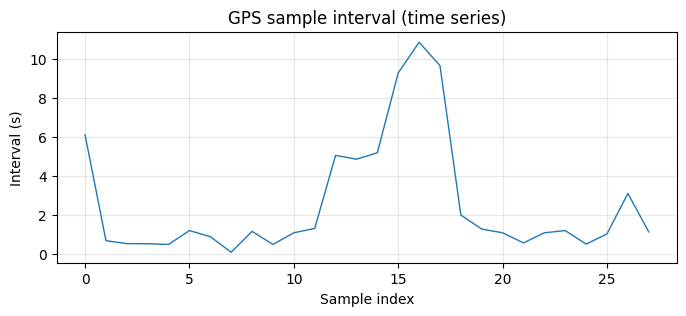

In [36]:
# deltas_s 시계열 시각화
import matplotlib.pyplot as plt

if deltas_ns:
    deltas_s = [d / 1e9 for d in deltas_ns]
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.plot(deltas_s, color='#1f77b4', linewidth=1)
    ax.set_title('GPS sample interval (time series)')
    ax.set_xlabel('Sample index')
    ax.set_ylabel('Interval (s)')
    ax.grid(True, alpha=0.3)
    plt.show()
else:
    print('not enough samples to plot')


In [ ]:
# 지도 생성 (folium)
import folium
from IPython.display import display

center = points[0] if points else (0, 0)

m = folium.Map(location=center, zoom_start=18, tiles='OpenStreetMap')

if points:
    folium.PolyLine(points, color='#1f77b4', weight=3).add_to(m)
    for p in points:
        folium.CircleMarker(p, radius=3, color='#ff7f0e', weight=1, fill=True, fill_opacity=0.8).add_to(m)

    folium.CircleMarker(points[0], radius=6, color='green', fill=True, fill_opacity=0.9, popup='Start').add_to(m)
    folium.CircleMarker(points[-1], radius=6, color='red', fill=True, fill_opacity=0.9, popup='End').add_to(m)

# m.save(data_dir / "Location_map.html")
display(m)


In [38]:
# 하버사인 거리 합산 (meters)
R = 6371000.0
def haversine(p1, p2):
    lat1, lon1 = p1
    lat2, lon2 = p2
    phi1 = math.radians(lat1)
    phi2 = math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlambda/2)**2
    return 2*R*math.atan2(math.sqrt(a), math.sqrt(1-a))

total_distance_m = 0.0
if len(points) >= 2:
    total_distance_m = sum(haversine(points[i-1], points[i]) for i in range(1, len(points)))

total_distance_m


20.46545922922733